# Data Science in Psychology and Neuroscience

## Class info:
* Week #10
* Day: March 24, 2026
* Time: 9:30—10:45 AM
* Location: Logan Hall 125
* <a href="https://forms.microsoft.com/r/26vAcJWrwH">Click here to submit your attendance for Week 10, Question 17!</a>
  
## Instructor info:
* Dr. Jeremy Hogeveen
* jhogeveen@unm.edu
* Logan Hall 281 (Office Hours By Appointment)
  
## Syllabus:
* <a href="https://www.dropbox.com/scl/fi/6fs6fi4kvkwtxn7j7x8ua/PSY450650_DSPN_Spring2026_Syllabus.pdf?rlkey=148e5t4ah8q2n1daclt7mp0h6&dl=0">Download here</a>

## Today's topic:
* So, you want to model some data...
    * Examples.

# Section 1: So you want to model some data?

<img src="img/what-does-that-mean-david.gif" width=300>

## 1.1 What did you find?
* Let's say you have...
1. Acquired some data
2. Wrangled the data
3. Computed descriptive statistics (central tendencies, variance, etc.)
4. Generated some visualizations
* Remaining questions: What did you find?

### __Inferential (or predictive) modeling is used to generate an interim answer about your pre-defined research questions / hypotheses__.

## Which model is appropriate?

<img src="img/decision_tree.png" width=450>

__Key questions:__
1. Are the main outcome measures you're interested in continuous or categorical?
2. If continuous, is your research question about associations or differences?
3. If continuous + associations...
    - Independent and dependent variable?
4. If continuous + differences...
    - Differences between what?

# Section 2: Modeling Exercise 1

### 2.1 Background: _Gebotys and Roberts (1989) were interested in examining the effects of several variables on the “seriousness rating of the crime”. The variables to be examined within this example are “age” (in years), the “amount of television news watched in hours per week” (i.e., ‘tvnews’), and whether or not the respondents had experience being a victim of crime in the past (i.e., 'experience')._

In [1]:
suppressPackageStartupMessages(library(tidyverse))

In [2]:
df <- tibble(pid  = c(1,2,3,4,5,6,7,8,9,10,11),
             age = c(10,25,26,25,30,34,40,40,40,25,80),
             tv_news = c(4.0,5.0,5.0,4.5,6.0,7.0,5.5,6.0,7.0,8.5,9.0),
             experience = as_factor(c(0,0,0,0,0,1,0,1,1,1,1)),
             crime_seriousness = c(21,28,27,26,33,36,31,35,41,80,95))
df

pid,age,tv_news,experience,crime_seriousness
<dbl>,<dbl>,<dbl>,<fct>,<dbl>
1,10,4.0,0,21
2,25,5.0,0,28
3,26,5.0,0,27
4,25,4.5,0,26
5,30,6.0,0,33
6,34,7.0,1,36
7,40,5.5,0,31
8,40,6.0,1,35
9,40,7.0,1,41


### 2.2 Exercise 1, research question 1: Is there an association between TV news viewership and crime seriousness ratings?

`geom_smooth()` using formula = 'y ~ x'


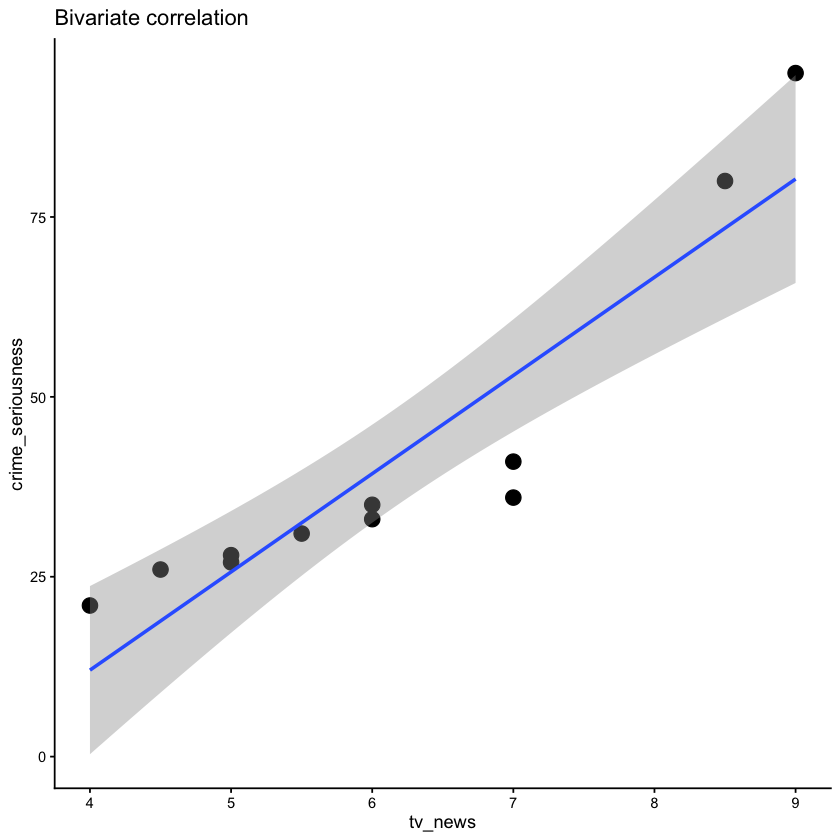

In [3]:
ggplot(df,aes(x=tv_news,y=crime_seriousness)) +
    geom_point(size=4) +
    geom_smooth(method=lm) +
    theme_classic() +
    ggtitle('Bivariate correlation')

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: label.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?”


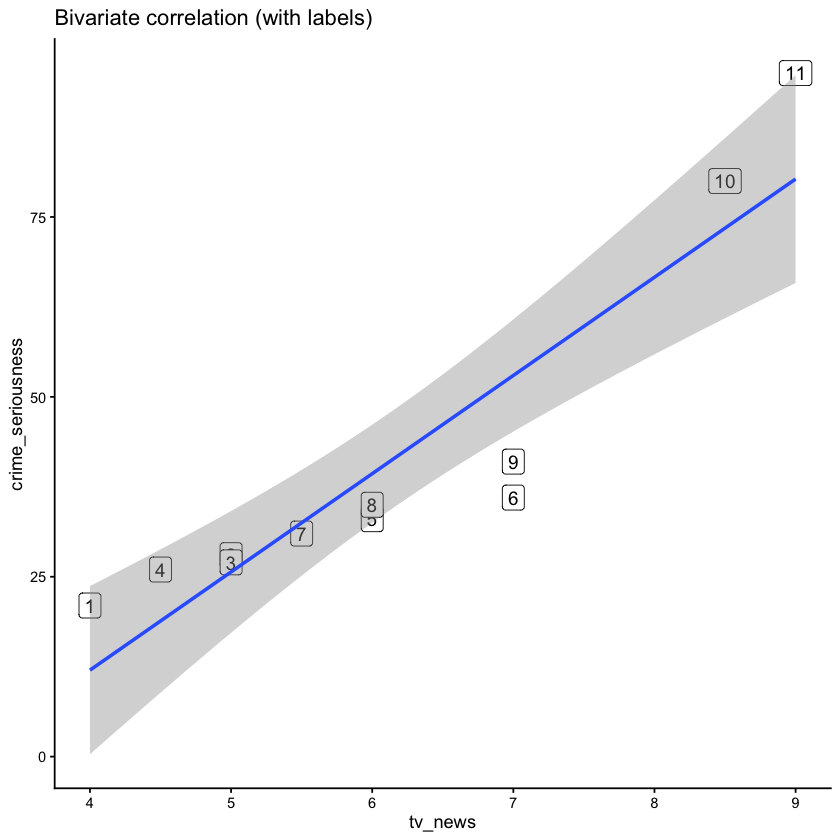

In [4]:
ggplot(df,aes(x=tv_news,y=crime_seriousness,label=pid)) +
    geom_label(size=4) +
    geom_smooth(method=lm) +
    theme_classic() +
    ggtitle('Bivariate correlation (with labels)')

### __Linear relationship: Determine whether the variables change together at a constant rate__

In [5]:
# testing a linear relationship 
m_r <- cor.test(df$tv_news,df$crime_seriousness)
m_r


	Pearson's product-moment correlation

data:  df$tv_news and df$crime_seriousness
t = 6.9342, df = 9, p-value = 6.803e-05
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.7073480 0.9787848
sample estimates:
      cor 
0.9177872 


### __Monotonic relationship: the variables change together, but not _necessarily_ at a constant rate.__

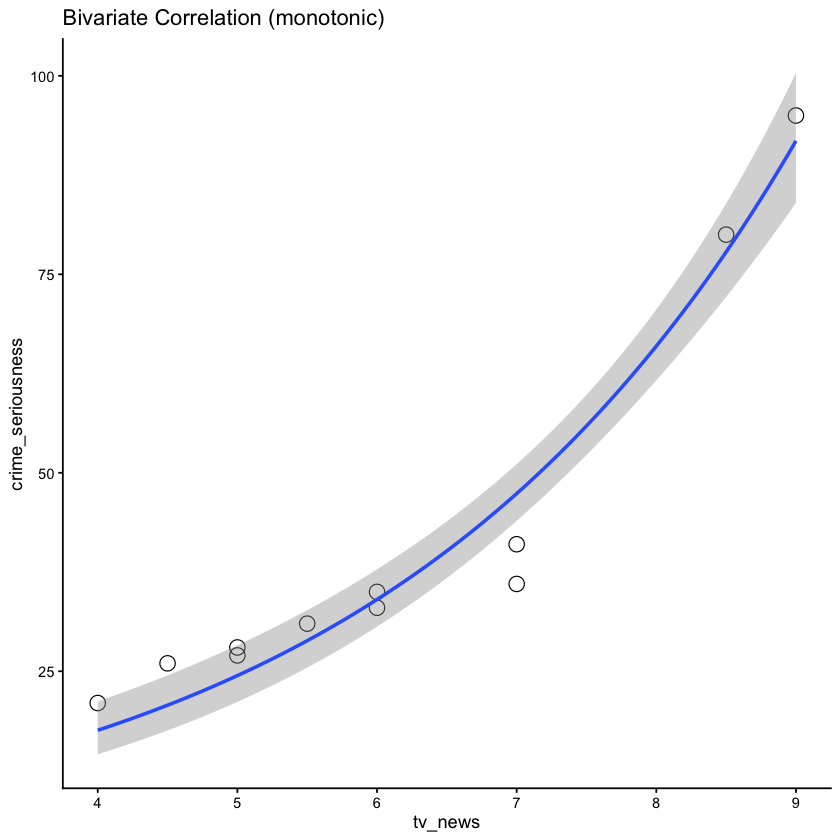

In [6]:
ggplot(df,aes(x=tv_news,y=crime_seriousness)) +
    geom_point(size=4,shape=21) +
    geom_smooth(method = "glm",formula = y ~ x, method.args = list(family = gaussian(link = 'log'))) +
    theme_classic() +
    ggtitle('Bivariate Correlation (monotonic)')

In [7]:
# testing the monotonic relationship between variables
m_rho <- cor.test(df$tv_news,df$crime_seriousness,method='spearman')
m_rho

Warning message in cor.test.default(df$tv_news, df$crime_seriousness, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  df$tv_news and df$crime_seriousness
S = 1.5051, p-value = 1.05e-09
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.9931584 


### 2.2 Exercise 1, research question 2: Does age predict tv news viewership?

`geom_smooth()` using formula = 'y ~ x'


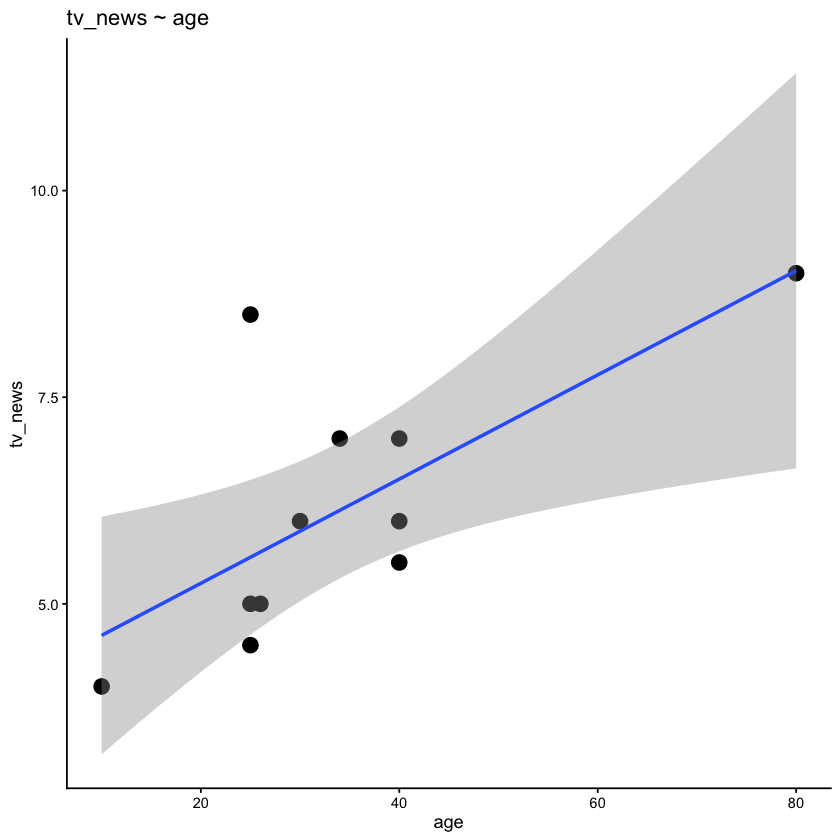

In [8]:
ggplot(df,aes(x = age, y = tv_news)) +
    geom_point(size=4) +
    geom_smooth(method=lm) +
    theme_classic() +
    ggtitle('tv_news ~ age')

### __Linear regression: Does $y$ change at a constant rate as a function of $x$.__

In [9]:
m_regr <- lm(tv_news ~ age,df)
summary(m_regr)


Call:
lm(formula = tv_news ~ age, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.0633 -0.6220 -0.5089  0.3063  2.9367 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  3.98732    0.82209   4.850 0.000908 ***
age          0.06304    0.02162   2.916 0.017144 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.208 on 9 degrees of freedom
Multiple R-squared:  0.4858,	Adjusted R-squared:  0.4287 
F-statistic: 8.503 on 1 and 9 DF,  p-value: 0.01714


In [10]:
# set float notation
# options(scipen = 999)

# adding z-transformed values 
df <- df %>%
    mutate(zcrime = scale(crime_seriousness),
           ztv_news = scale(tv_news),
           zage = scale(age))


# rerunning model with zvars
m_zregr <- lm(ztv_news ~ zage, df)
summary(m_zregr)


Call:
lm(formula = ztv_news ~ zage, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.6653 -0.3892 -0.3184  0.1917  1.8374 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept) -4.246e-18  2.279e-01   0.000   1.0000  
zage         6.970e-01  2.390e-01   2.916   0.0171 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7559 on 9 degrees of freedom
Multiple R-squared:  0.4858,	Adjusted R-squared:  0.4287 
F-statistic: 8.503 on 1 and 9 DF,  p-value: 0.01714


### 2.3 Exercise 1, research question 3: Does the effect of TV watching on crime seriousness ratings vary as a function of age?

In [13]:
# main effects model
m_regr_main <- lm(zcrime ~ ztv_news + zage,df)
summary(m_regr_main)

# interaction model
m_regr_interaction <- lm(zcrime ~ ztv_news * zage,df)
summary(m_regr_interaction)


Call:
lm(formula = zcrime ~ ztv_news + zage, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.67406 -0.23537  0.05205  0.35156  0.47868 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept) 3.329e-16  1.315e-01   0.000   1.0000   
ztv_news    8.451e-01  1.923e-01   4.395   0.0023 **
zage        1.043e-01  1.923e-01   0.543   0.6022   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.436 on 8 degrees of freedom
Multiple R-squared:  0.8479,	Adjusted R-squared:  0.8099 
F-statistic:  22.3 on 2 and 8 DF,  p-value: 0.0005348



Call:
lm(formula = zcrime ~ ztv_news * zage, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.58881 -0.14457  0.07144  0.15597  0.42823 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -0.1537     0.1230  -1.250 0.251396    
ztv_news        0.9701     0.1617   5.998 0.000543 ***
zage           -0.2107     0.2024  -1.041 0.332557    
ztv_news:zage   0.2426     0.1021   2.376 0.049201 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.3468 on 7 degrees of freedom
Multiple R-squared:  0.9158,	Adjusted R-squared:  0.8797 
F-statistic: 25.38 on 3 and 7 DF,  p-value: 0.0003897


In [15]:


# Creating an interaction plotting function, inspired by sjPlot


# For categorical moderator term
plot_interaction <- function(data, outcome, predictor, moderator) {
  
  # Force the moderator to be a factor (categorical)
  data[[moderator]] <- as.factor(data[[moderator]])
  
  # Fit the model
  formula_str <- paste(outcome, "~", predictor, "*", moderator)
  model <- lm(as.formula(formula_str), data = data)
  
  # Find the min and max of the predictor, and get all categories of the moderator
  grid_data <- expand.grid(
    pred_vals = seq(min(data[[predictor]], na.rm = TRUE), 
                    max(data[[predictor]], na.rm = TRUE), 
                    length.out = 100),
    mod_vals = levels(data[[moderator]])
  )
  
  # Rename grid columns so the predict() function recognizes them
  names(grid_data) <- c(predictor, moderator)
  
  # Pull model predictions and confidence intervals
  predictions <- predict(model, newdata = grid_data, interval = "confidence")
  plot_data <- cbind(grid_data, predictions)
  
  # Plot the interaction!
  # Passing string variables into R functions is difficult, we use the .data[[variablestring]] approach based on advice from stack overflow
  ggplot(plot_data, aes(x = .data[[predictor]], y = fit, 
                        color = .data[[moderator]], 
                        fill = .data[[moderator]])) +
    geom_ribbon(aes(ymin = lwr, ymax = upr), alpha = 0.2, color = NA) +
    geom_line(linewidth = 1.2) +
    geom_point(data = data, aes(x = .data[[predictor]], y = .data[[outcome]]), alpha = 0.4) +
    labs(
      title = paste(predictor, "and", moderator," interaction plot."),
      y = paste("Predicted", outcome),
      color = moderator,
      fill = moderator
    ) +
    theme_classic()
}

plot_continuous_interaction <- function(data, outcome, predictor, moderator) {
  formula_str <- paste(outcome, "~", predictor, "*", moderator)
  model <- lm(as.formula(formula_str), data = data)
  # Using "spotlight" approach to identify low, med, and high mod values
  mod_mean <- mean(data[[moderator]], na.rm = TRUE)
  mod_sd   <- sd(data[[moderator]], na.rm = TRUE)
  spotlight_vals <- c(mod_mean - mod_sd, mod_mean, mod_mean + mod_sd)
  spotlight_labels <- c("Low (-1 SD)", "Mean", "High (+1 SD)") 
  # Create grid using only the spotlight values of moderator
  grid_data <- expand.grid(
    pred_vals = seq(min(data[[predictor]], na.rm = TRUE), 
                    max(data[[predictor]], na.rm = TRUE), 
                    length.out = 100),
    mod_vals = spotlight_vals
  )
  names(grid_data) <- c(predictor, moderator)
  # Pull predictions and wrangle data together 
  predictions <- predict(model, newdata = grid_data, interval = "confidence")
  plot_data <- cbind(grid_data, predictions)
  
  # Convert the moderator in the PLOT DATA to a factor for plotting
  plot_data[[moderator]] <- factor(plot_data[[moderator]], 
                                   levels = spotlight_vals, 
                                   labels = spotlight_labels)
  # Plot the interaction
  ggplot(plot_data, aes(x = .data[[predictor]], y = fit, 
                        color = .data[[moderator]], 
                        fill = .data[[moderator]])) +
    geom_ribbon(aes(ymin = lwr, ymax = upr), alpha = 0.2, color = NA) +
    geom_line(linewidth = 1.2) +
    labs(
      title = paste(predictor, "and", moderator," interaction plot."),
      y = paste("Predicted", outcome),
      color = moderator,
      fill = moderator
    ) +
    theme_classic()
}

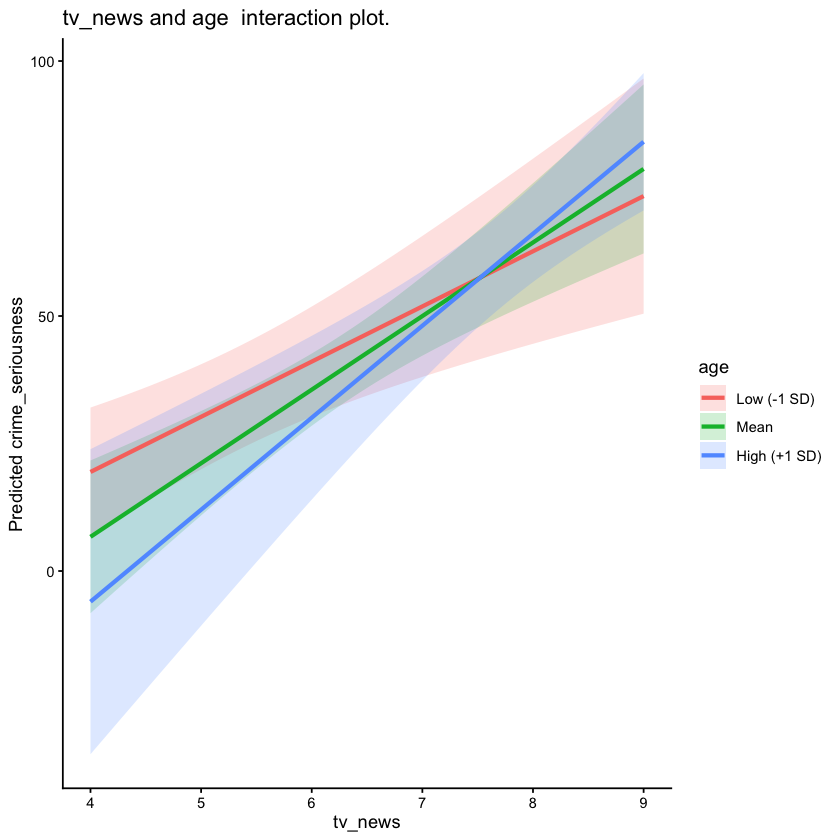

In [20]:
plot_continuous_interaction(df, "crime_seriousness","tv_news", "age")